# Exploratory Data Analysis: ETTh1

**Dataset**: ETT-small (Electricity Transformer Temperature - Hourly)

**Goal**: Understand the data characteristics before modeling

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src.data_prep import load_etth1, clean_data, chronological_split

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Imports successful!")

Imports successful!


## 1. Load Data

In [2]:
df = load_etth1(data_dir='../data/raw')
df = clean_data(df)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head(10)

Dataset shape: (17420, 7)
Date range: 2016-07-01 00:00:00 to 2018-06-26 19:00:00

Columns: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

First few rows:


,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000
2016-07-01 05:00:00,5.626,2.143,1.528,0.533,4.051,1.371,21.174000
2016-07-01 06:00:00,7.167,2.947,2.132,0.782,5.026,1.858,22.792000
2016-07-01 07:00:00,7.435,3.282,2.310,1.031,5.087,2.224,23.143999
2016-07-01 08:00:00,5.559,3.014,2.452,1.173,2.955,1.432,21.667000


## 2. Target Variable: OT (Oil Temperature)

OT (Oil Temperature) Statistics:
count    17420.000000
mean        13.324672
std          8.566946
min         -4.080000
25%          6.964000
50%         11.396000
75%         18.079000
max         46.007000
Name: OT, dtype: float64


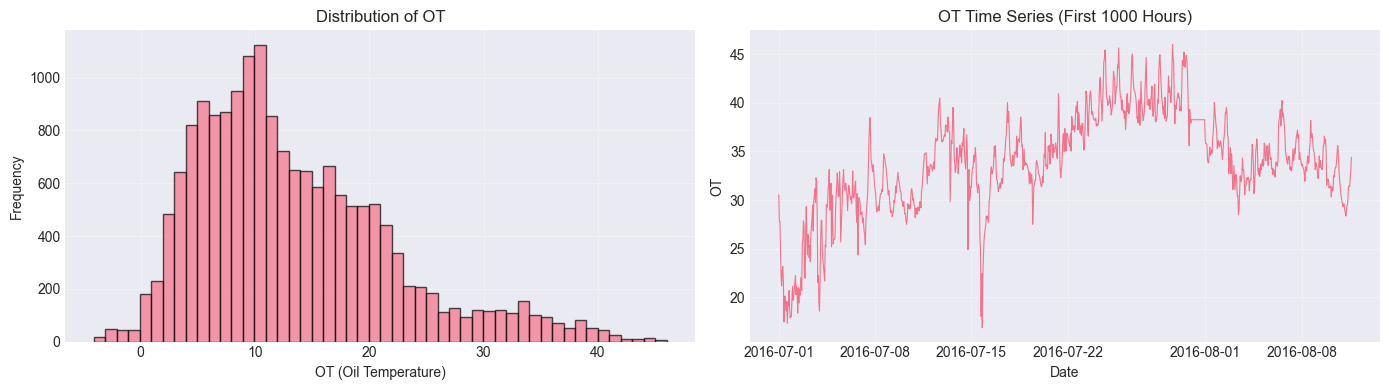

In [3]:
print("OT (Oil Temperature) Statistics:")
print(df['OT'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
axes[0].hist(df['OT'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('OT (Oil Temperature)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of OT')
axes[0].grid(alpha=0.3)

# Time series (first 1000 hours)
axes[1].plot(df.index[:1000], df['OT'][:1000], linewidth=0.8)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('OT')
axes[1].set_title('OT Time Series (First 1000 Hours)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Seasonality Analysis

**Hypothesis**: Hourly electricity data should show 24-hour (daily) seasonality

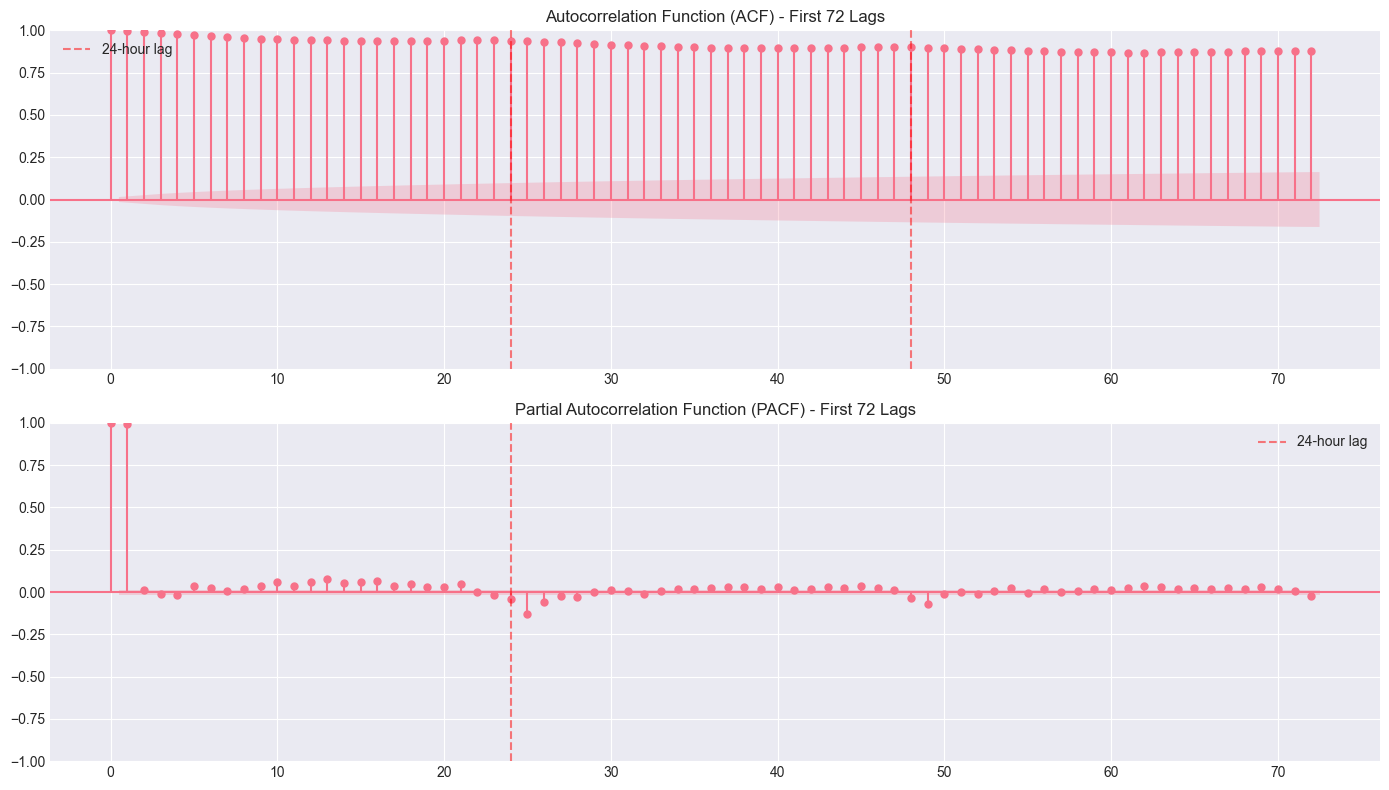


📊 Observation: Strong peaks at lag 24, 48 confirm daily seasonality


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ACF
plot_acf(df['OT'].dropna(), lags=72, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) - First 72 Lags')
axes[0].axvline(x=24, color='r', linestyle='--', alpha=0.5, label='24-hour lag')
axes[0].axvline(x=48, color='r', linestyle='--', alpha=0.5)
axes[0].legend()

# PACF
plot_pacf(df['OT'].dropna(), lags=72, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF) - First 72 Lags')
axes[1].axvline(x=24, color='r', linestyle='--', alpha=0.5, label='24-hour lag')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n📊 Observation: Strong peaks at lag 24, 48 confirm daily seasonality")

## 4. Hourly Patterns

Average OT by hour of day

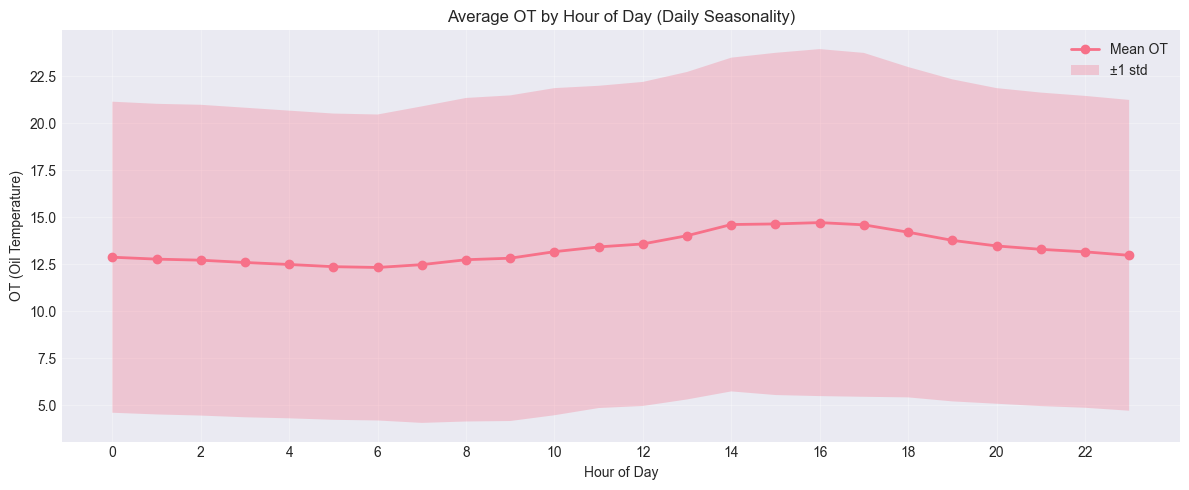


📊 Clear daily pattern: Temperature varies by ~10 degrees across the day


In [5]:
df_with_hour = df.copy()
df_with_hour['hour'] = df_with_hour.index.hour

hourly_avg = df_with_hour.groupby('hour')['OT'].agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_avg.index, hourly_avg['mean'], marker='o', linewidth=2, label='Mean OT')
ax.fill_between(hourly_avg.index, 
                hourly_avg['mean'] - hourly_avg['std'],
                hourly_avg['mean'] + hourly_avg['std'],
                alpha=0.3, label='±1 std')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('OT (Oil Temperature)')
ax.set_title('Average OT by Hour of Day (Daily Seasonality)')
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Clear daily pattern: Temperature varies by ~10 degrees across the day")

## 5. Covariate Relationships

How do usage variables relate to OT?

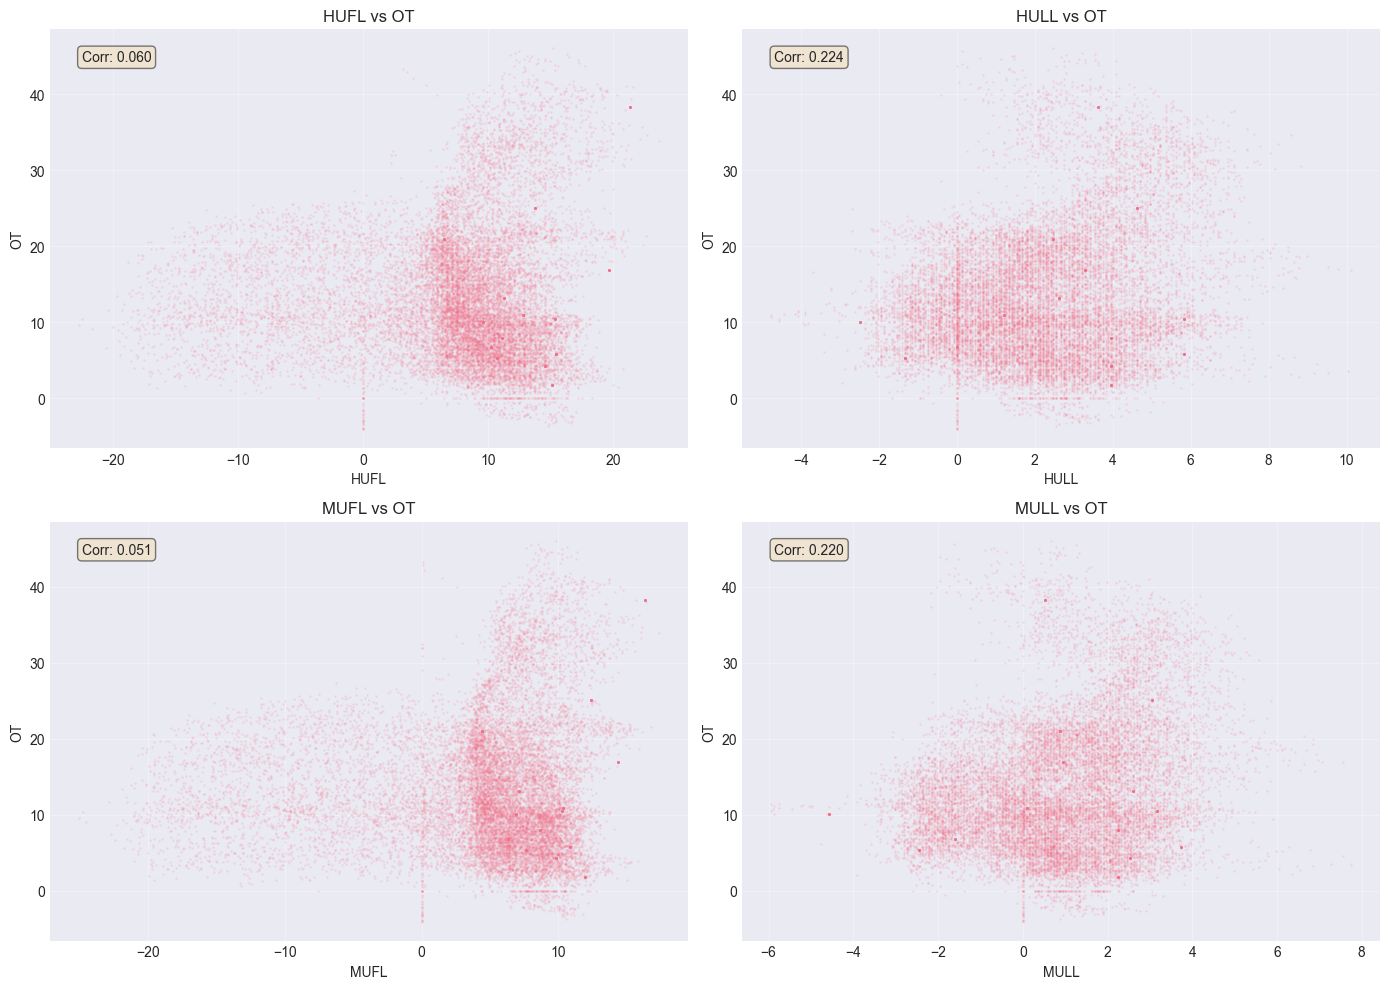


📊 Covariates show moderate correlation with OT - useful for TFT


In [6]:
covariates = ['HUFL', 'HULL', 'MUFL', 'MULL']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, cov in enumerate(covariates):
    axes[i].scatter(df[cov], df['OT'], alpha=0.1, s=1)
    axes[i].set_xlabel(cov)
    axes[i].set_ylabel('OT')
    axes[i].set_title(f'{cov} vs OT')
    axes[i].grid(alpha=0.3)
    
    # Correlation
    corr = df[[cov, 'OT']].corr().iloc[0, 1]
    axes[i].text(0.05, 0.95, f'Corr: {corr:.3f}', 
                transform=axes[i].transAxes, 
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n📊 Covariates show moderate correlation with OT - useful for TFT")

## 6. Train/Val/Test Splits

**Critical**: Chronological splits prevent data leakage

Chronological splits:
  Train: 2016-07-01 00:00:00 to 2017-09-09 11:00:00 (10452 hours)
  Val:   2017-09-09 12:00:00 to 2018-02-01 15:00:00 (3484 hours)
  Test:  2018-02-01 16:00:00 to 2018-06-26 19:00:00 (3484 hours)


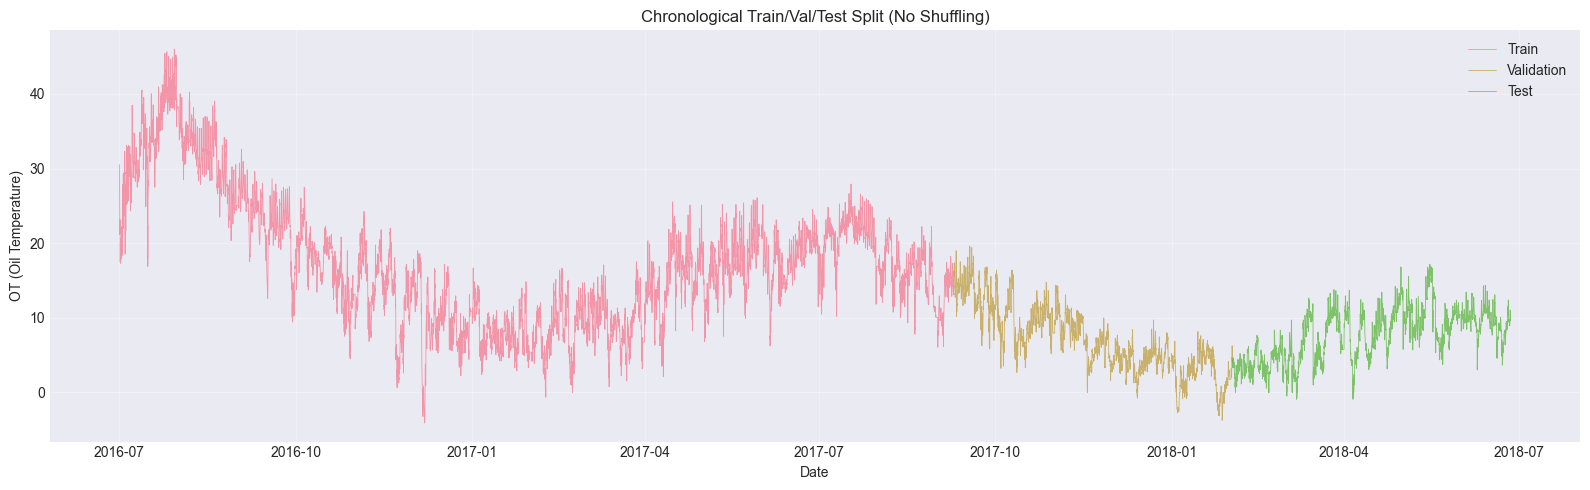


✅ Test set is entirely in the future - no leakage possible


In [7]:
train_idx, val_idx, test_idx = chronological_split(df, train_frac=0.6, val_frac=0.2)

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df.loc[train_idx].index, df.loc[train_idx, 'OT'], 
        label='Train', alpha=0.7, linewidth=0.6)
ax.plot(df.loc[val_idx].index, df.loc[val_idx, 'OT'], 
        label='Validation', alpha=0.7, linewidth=0.6)
ax.plot(df.loc[test_idx].index, df.loc[test_idx, 'OT'], 
        label='Test', alpha=0.7, linewidth=0.6)

ax.set_xlabel('Date')
ax.set_ylabel('OT (Oil Temperature)')
ax.set_title('Chronological Train/Val/Test Split (No Shuffling)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Test set is entirely in the future - no leakage possible")

## 7. Volatility Analysis

Does OT volatility change over time?

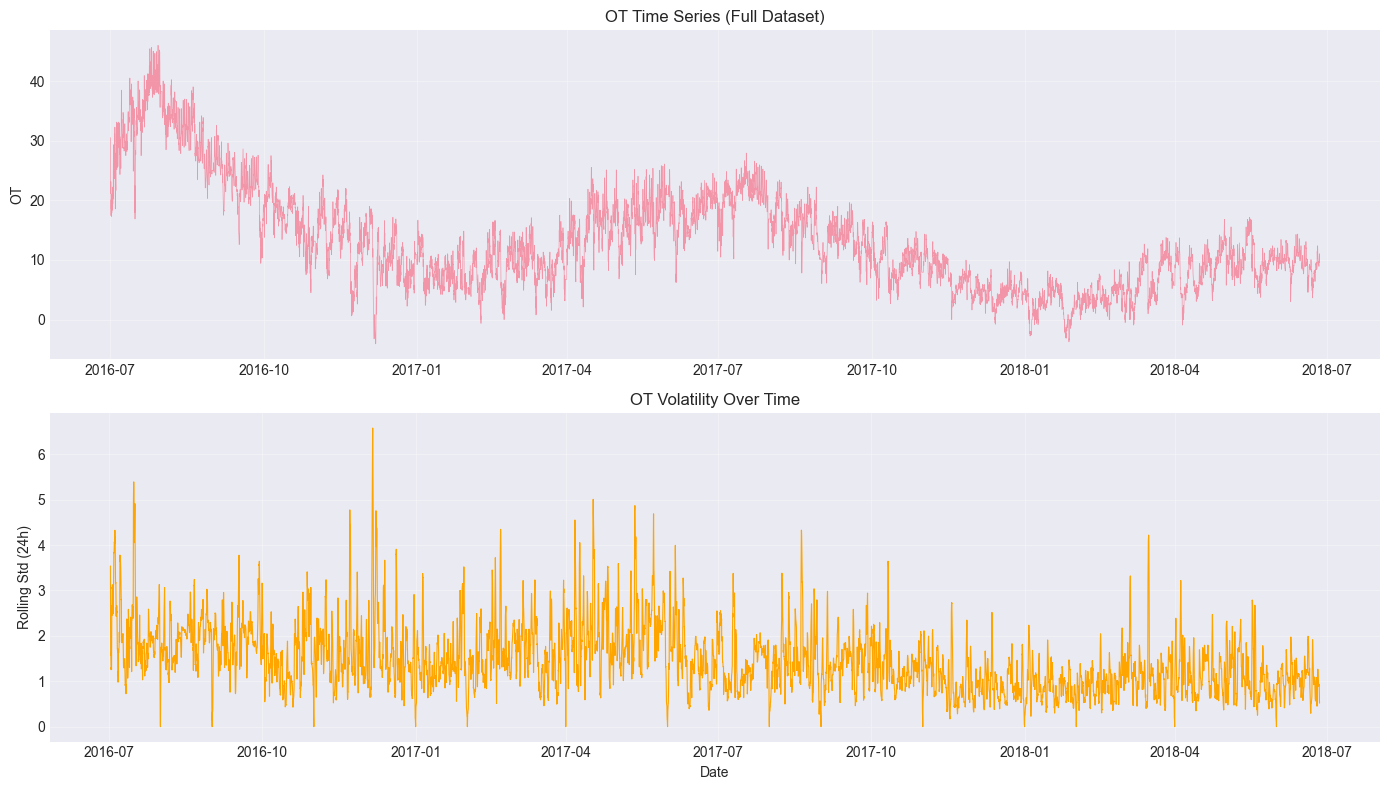


📊 Volatility varies over time - justifies GMM regime detection


In [8]:
# Rolling std as volatility proxy
df['rolling_std_24'] = df['OT'].rolling(24).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# OT time series
axes[0].plot(df.index, df['OT'], linewidth=0.5, alpha=0.7)
axes[0].set_ylabel('OT')
axes[0].set_title('OT Time Series (Full Dataset)')
axes[0].grid(alpha=0.3)

# Volatility
axes[1].plot(df.index, df['rolling_std_24'], linewidth=0.8, color='orange')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Rolling Std (24h)')
axes[1].set_title('OT Volatility Over Time')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Volatility varies over time - justifies GMM regime detection")

## 8. Correlation Matrix

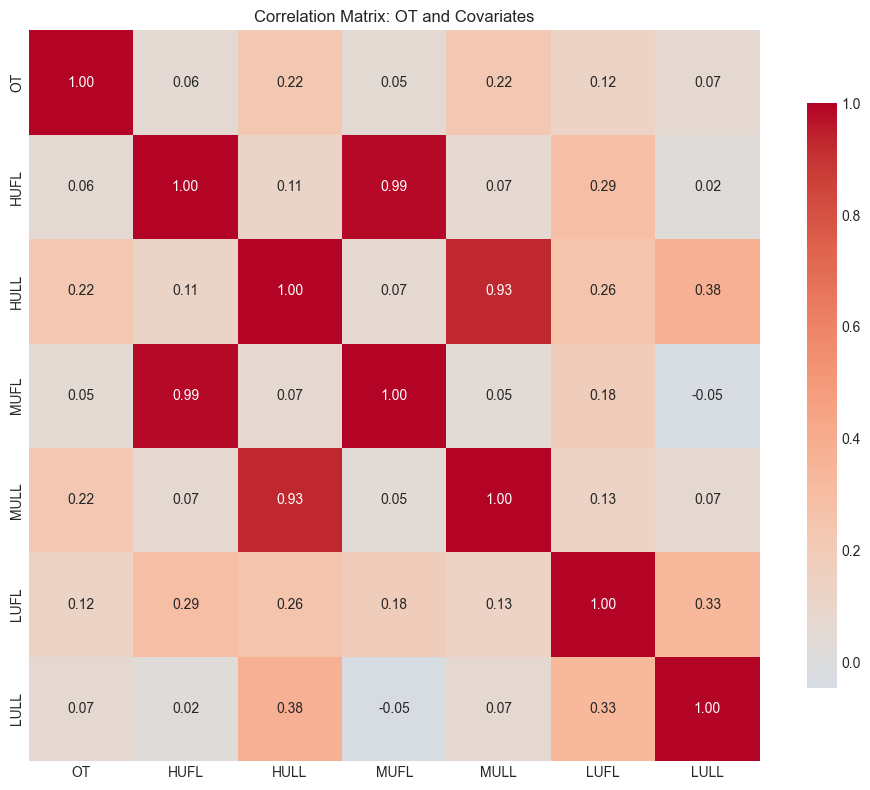


📊 OT correlates moderately with usage variables (0.2-0.5 range)


In [9]:
corr_matrix = df[['OT', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix: OT and Covariates')
plt.tight_layout()
plt.show()

print("\n📊 OT correlates moderately with usage variables (0.2-0.5 range)")

## 9. Stationarity Check

Is the data stationary? (Important for SARIMAX)

In [10]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['OT'].dropna())

print("Augmented Dickey-Fuller Test:")
print(f"  ADF Statistic: {result[0]:.4f}")
print(f"  p-value: {result[1]:.4f}")
print(f"  Critical values:")
for key, value in result[4].items():
    print(f"    {key}: {value:.4f}")

if result[1] < 0.05:
    print("\n✅ Data is stationary (p < 0.05) - no differencing needed")
else:
    print("\n⚠️ Data may be non-stationary - consider differencing")

Augmented Dickey-Fuller Test:
  ADF Statistic: -3.4880
  p-value: 0.0083
  Critical values:
    1%: -3.4307
    5%: -2.8617
    10%: -2.5669

✅ Data is stationary (p < 0.05) - no differencing needed


## 10. Key Insights for Modeling

### What we learned:

1. **Strong daily seasonality** (24-hour period)
   - Justifies SARIMAX with seasonal_order=(1,0,1,24)

2. **Time-varying volatility**
   - Justifies GMM regime detection

3. **Moderate covariate correlations**
   - HUFL/HULL/MUFL/MULL useful for TFT

4. **Relatively stationary**
   - No differencing needed (d=0 in SARIMAX)

5. **Smooth with occasional spikes**
   - Linear model will capture most signal
   - TFT handles residual nonlinearity

### Data Leakage Prevention:

- ✅ Chronological splits (test is future)
- ✅ No shuffling in DataLoaders
- ✅ All rolling features use `.shift(1)` (causal)
- ✅ GMM fitted on training data only

**Ready for modeling!**